## Cleanup the datacenter CSV

In [3]:
import csv

input_file = "../../data/temp/datacenters.csv"
output_file = "../../data/temp/datacenters_cleaned.csv"

correct_columns = 6

def fix_line(line):
    """Fix a line by combining fields until quotes are balanced."""
    parts = []
    current = ''
    in_quotes = False
    
    for char in line:
        if char == '"':
            in_quotes = not in_quotes
            current += char
        elif char == ',' and not in_quotes:
            parts.append(current.strip())
            current = ''
        else:
            current += char
    parts.append(current.strip())
    return parts

with open(input_file, 'r', encoding='utf-8') as infile, \
     open(output_file, 'w', newline='', encoding='utf-8') as outfile:
    
    writer = csv.writer(outfile)
    
    for line in infile:
        line = line.strip()
        if not line:
            continue
        
        row = fix_line(line)
        
        if len(row) > correct_columns:
            # Merge extra columns into the first column
            row = [','.join(row[:len(row) - (correct_columns - 1)])] + row[-(correct_columns - 1):]
        elif len(row) < correct_columns:
            # Pad missing columns
            row += [''] * (correct_columns - len(row))
        
        writer.writerow(row)

### Verify CSV can be read into pandas 

In [4]:
import pandas as pd

datacenters_raw = pd.read_csv('../../data/temp/datacenters_cleaned.csv')
datacenters_raw[:5]

,Name,State,Operator,Address,Year Opened,Source URL
0,2323 Bryan Street (Dfw10),Texas,Digital Realty,"""2323 Bryan St, Dallas, TX 75201, USA""",1989,https://baxtel.com/data-center/2323-bryan-stre...
1,4025 Midway Rd (Dfw11),Texas,Digital Realty,"""4025 Midway Rd, Carrollton, TX 75007, USA""",2000,https://baxtel.com/data-center/digital-realty-...
2,H5Colo Inc.,Texas,H5 Colo,"""12712 Park Central Dr, Dallas, TX 75251, USA""",2010,https://www.h5colo.com/about
3,1232 Alma Road (Dfw16),Texas,Digital Realty,"""1232 Alma Rd, Richardson, TX 75081, USA""",2001,https://baxtel.com/data-center/digital-realty-...
4,8435 Stemmons Freeway (Dfw36),Texas,Digital Realty,"""8435 Stemmons Fwy, Dallas, TX 75247, USA""",2001,https://baxtel.com/data-center/8435-stemmons-f...


### Handle problematic rows

In [5]:
problem_children = datacenters_raw.copy()

# Make sure it's string
problem_children['Year Opened'] = problem_children['Year Opened'].astype(str)

# case 1: year opened is already just a clean 4 digit year
problem_children['year'] = (
    problem_children['Year Opened']
        .astype(str)
        .str.extract(r'\b(\d{4})\b')[0]
        .astype(float)
)

# case 2: contains 'Operational - XXXX' or 'Planned - XXXX' in any columns
row_text = (problem_children.astype(str).apply(lambda row: ' '.join(row), axis=1))
extracted_year = row_text.str.extract(r'(?:Operational|Planned)\s*[-–]\s*(\d{4})')[0]
problem_children['year'] = (problem_children['year'].fillna(extracted_year))

# cast back to numeric
problem_children['year'] = pd.to_numeric(problem_children['year'], errors='coerce')

In [6]:
problem_children.sort_values('year').tail(50)

,Name,State,Operator,Address,Year Opened,Source URL,year
3558,Vantage - Pittsboro Dc1,Indiana,Vantage Data Centers,"""County Roads 500 E, 850 N, & 1000 N, Pittsbor...",2032,https://vantage-dc.com/,2032.0
3596,Google Fort Wayne - Building 7,Indiana,Google,"""6015 Adams Center Rd, Fort Wayne, IN 46816, USA""",2032,https://www.google.com/about/datacenters/,2032.0
3594,Google Fort Wayne - Building 6,Indiana,Google,"""6015 Adams Center Rd, Fort Wayne, IN 46816, USA""",2032,https://www.google.com/about/datacenters/,2032.0
4141,Project Washington South Dc1,Delaware,Starwood Digital Ventures,"""825 Governor Lea Rd, New Castle, DE 19720, USA""",2032,profile (planned),2032.0
4139,Project Washington North Dc4,Delaware,Starwood Digital Ventures,"""River Rd, New Castle, DE 19720, USA""",2032,profile (planned),2032.0
1534,"Project West,GA",Unknown Company,"""Pearl Harbor Memorial Hwy (I-85) & Hamilton R...",Planned – 2032,1.5M sq ft campus on 513 acres,$6B build-out,2032.0
3479,Meta Altoona - Building 10,Iowa,Meta,"""2500 Share Wy NW, Altoona, IA 50009, USA""",2032,https://datacenters.atmeta.com/,2032.0
3484,Meta Altoona - Building 9,Iowa,Meta,"""2500 Share Wy NW, Altoona, IA 50009, USA""",2032,https://datacenters.atmeta.com/,2032.0
1529,"Hampton Technology Park,GA,Unknown Company","""Lower Woolsey Rd, Hampton, GA 30228""",Planned – 2033,603-acre campus,up to five buildings,4M sq ft,2033.0
209,Acs Fort Worth - Building E,Texas,Grupo ACS,"""Hillwood Blvd | 76179 | Fort Worth | Texas | ...",2034**,(Same multi‑building project),2034.0


In [7]:
# handle outliers
manual_years = {
    1421: 2023,
    1436: 2015,
    1437: 2018,
    1487: 2023,
    452:  2027,
    904:  2025,
    906:  2026,
    907:  2025,
    914:  2026,
    918:  2026,
    928:  2025,
    935:  2025,
    938:  2025,
    943:  2026,
    3627: 2015,
    4070: 2026,
    4149: 2025
}

for idx, yr in manual_years.items():
    problem_children.loc[idx, 'year'] = yr

# drop Na
problem_children = problem_children.dropna()

# drop before 1980s
problem_children = problem_children[problem_children['year'] >= 1980]

In [8]:
problem_children.shape

(4117, 7)

### Cleanup State column

In [13]:
print(problem_children['State'].unique())

['Texas' 'NTT DATA' 'Cogent Communications' 'Riot Platforms'
 'Duos Edge AI' 'Hostway Services' 'Bestline Communications' 'NaviSite'
 'Five 9s Digital' 'T-Mobile US' '1606 Corp.' 'Virginia' 'Menlo Digital'
 '"Ashland Rd | 23059 | Glen Allen | Virginia | USA"'
 '"2840 Roxbury Rd | 23030 | Charles City | Virginia | USA"' 'EdgeCore'
 'Amazon AWS' 'Google' 'Meta'
 '"Orrock Ln | 22580 | Woodford | Virginia | USA"'
 'Commonwealth Technical Services' 'Solutrix' 'NetTek' 'Project Turbo'
 'Flex Data Center' 'Takanock' 'OnePartner' 'Washington'
 'The Westin Building' 'ISOMEDIA' 'ColoCenters' 'Optic Fusion' 'BitPusher'
 'WA' 'Georgia' 'GA' 'Tulix Systems' 'Atlas Development LLC' 'TA Realty'
 'Unknown Company' '"151 Etowah Ridge Trail SE, Cartersville, GA 30120"'
 '2015*' 'Southern Telecom' 'Bolingbroke Technology Center' 'Microsoft'
 '"McDonough Hampton Rd, Hampton, GA 30228"' 'American Tower Corporation'
 'Operational – 2023' '"11650 Great Oaks Way, Alpharetta, GA 30022"'
 'Strategic Datasphere'

In [16]:
import json
import re

states = pd.read_json("../../data/state_map.json", orient="index", typ='series')
state_names = set(states.values)
state_codes = set(states.keys())

def extract_state(row_text):
    # Normalize text
    text = str(row_text)
    
    # Search for full state names
    for name in state_names:
        if re.search(rf'\b{name}\b', text, flags=re.IGNORECASE):
            return name
    
    # Search for state codes
    for code in state_codes:
        if re.search(rf'\b{code}\b', text, flags=re.IGNORECASE):
            return code
    
    return None

problem_children['state_extracted'] = problem_children.apply(
    lambda row: extract_state(' '.join(row.astype(str))), axis=1)

In [20]:
state_name_to_code = {v: k for k, v in states.items()}

problem_children['state_code'] = problem_children['state_extracted'].map(
    lambda x: state_name_to_code.get(x.upper().title()) if x in state_name_to_code else x
)

In [23]:
print(problem_children['state_code'].nunique())
print(problem_children['state_code'].unique())

41
['TX' 'VA' 'KY' 'WA' 'NE' 'GA' 'CO' 'IL' 'MI' 'MT' 'WY' 'CA' 'MD' 'AK'
 'KS' 'MO' 'MN' 'FL' 'AZ' 'PA' 'NY' 'OH' 'CT' 'TN' 'LA' 'MA' 'ME' 'IA'
 'IN' 'NV' 'ID' 'WI' 'OR' 'UT' 'AL' 'OK' 'AR' 'MS' 'HI' 'DE' 'VT']


### Inspect distribution

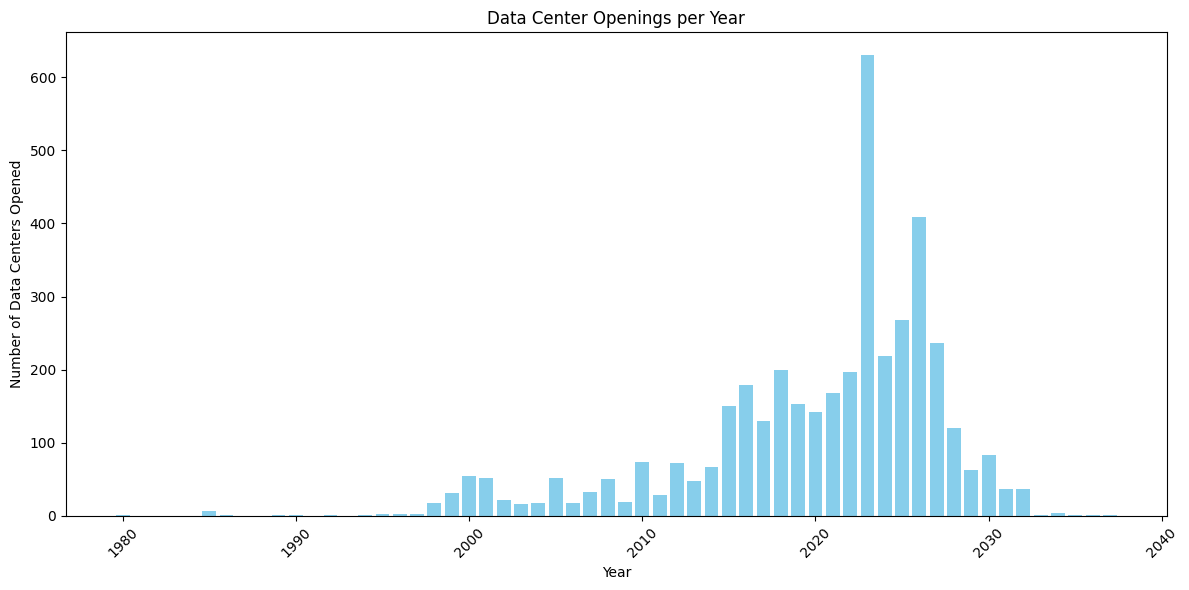

In [24]:
# Count datacenters per year
year_counts = problem_children['year'].value_counts().sort_index()

# Optional: convert to a DataFrame for plotting
year_counts_df = year_counts.reset_index()
year_counts_df.columns = ['year', 'count']

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.bar(year_counts_df['year'], year_counts_df['count'], color='skyblue')
plt.xlabel("Year")
plt.ylabel("Number of Data Centers Opened")
plt.title("Data Center Openings per Year")
plt.xticks(rotation=45)   # rotate x-axis labels if crowded
plt.tight_layout()
plt.show()

### Export cleaned dataset for use in other files

In [25]:
import pickle
problem_children.to_pickle('../../data/datacenters.pkl')